**Author:** Christopher Millward<br>
**Date:** August 18, 2026

The purpose of this notebook is to develop the statistics pipeline.

---

Questions:

1. how much did RTSA move (compared to non-op arm)
    - _(Optional)_ control for handedness?

2. how much motion was in each range of Elevation and POE
  - _(Optional)_ show mean elevation?
  - _(Optional)_ show mean IR_ER?


In [1]:
import os 
import sys

# set root folder to project root
root_path = os.path.abspath(os.path.join(".."))
if root_path not in sys.path:
    sys.path.insert(0, root_path)

# auto reload
%load_ext autoreload
%autoreload 2

In [2]:
import pickle
import pandas as pd
import ptitprince as pt
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from matplotlib.ticker import StrMethodFormatter
from scipy import stats

from config import RESULTS_PICKLE_PATH
from schema import ParticipantDetails

# import pickle file
with open(Path(RESULTS_PICKLE_PATH), 'rb') as f:
    results: list[ParticipantDetails] = pickle.load(f)

# set default themes
sns.set_theme(
    style="whitegrid",
    context="paper",
)
fig_size = (7.16, 5.0)  # 1 column width in inches
palette = "cividis"  # color palette for plots

## 1. How much did RTSA move?
Let's perform the following tasks:
- paired t-test
- present distributions of both op and non-op
    - table
    - raincloud plot with boxplot, paired lines, and significance (if applicable)

--- 
### Data prep
First, let's build a dataframe that has columns for:
- participant
- operated_total
- non_operated_total

**NOTE:**
For the sake of this analysis, we should only compare rtsa side to non-operated sides. So, let's filter the data to keep participants that had only RTSA on one arm and no TSA on the other.

In [3]:
# Only keep participants with exactly one RTSA and no implant on the other side
for participant in results:
    if participant.rtsa_side == 'both':
        print(f"Participant {participant.filename} has both sides operated.")
    if len(participant.operated) > 1:
        print(f"Participant {participant.filename} has more than one operated side.")

    if participant.rtsa_side is not None and participant.tsa_side is not None:
        print(f"Participant {participant.filename} has both rtsa and tsa.")

single_arm_participants = [
    participant for participant in results if (
            participant.rtsa_side is not None 
            and participant.rtsa_side != 'both'
            and participant.tsa_side is None
        )
    ]
print(f"\nNumber of all participants in results: {len(results)}")
print(f"Number of single-arm participants: {len(single_arm_participants)}")

Participant 1_R_MATRICES_NORM 2016-5-10 has both rtsa and tsa.

Number of all participants in results: 20
Number of single-arm participants: 19


In [4]:
# create df with participant, operated, non_operated
rows = []
for idx, participant in enumerate(single_arm_participants):
    vals = {
        'participant': participant.filename,
        'Operated': participant.operated[0].humerothoracic.trace_total,
        'Non-operated': participant.non_operated[0].humerothoracic.trace_total
    }
    rows.append(vals)

cumulative_totals = pd.DataFrame(rows)

print(cumulative_totals.head().to_markdown(index=False))

| participant                 |   Operated |   Non-operated |
|:----------------------------|-----------:|---------------:|
| 1_R_MATRICES_NORM 2016-5-5  |   15149.6  |       17467.5  |
| 1_R_MATRICES_NORM 2016-5-6  |   19398.1  |       19499.2  |
| 1_R_MATRICES_NORM 2016-6-22 |    7370.6  |        9154.81 |
| 1_R_MATRICES_NORM 2016-6-23 |    7755.94 |        6007.16 |
| 1_R_MATRICES_NORM 2016-6-30 |   26538.2  |       27373.6  |


In [5]:
# run t-test
t_stat, p_value = stats.ttest_rel(
    cumulative_totals['Operated'], 
    cumulative_totals['Non-operated']
)

print(f"t-statistic: {t_stat:.2f}")
print(f"p-value: {p_value:.2f}")

t-statistic: -1.07
p-value: 0.30


In [10]:
# print out table showing n, mean, std, and p-value for op and non-op
summary_table = pd.DataFrame({
    "Arm": ["Operated", "Non-operated"],
    "n": [cumulative_totals["Operated"].shape[0], cumulative_totals["Non-operated"].shape[0]],
    "Mean": [cumulative_totals["Operated"].mean(), cumulative_totals["Non-operated"].mean()],
    "Std": [cumulative_totals["Operated"].std(), cumulative_totals["Non-operated"].std()],
    "p-value": [p_value, p_value]
    })

print(summary_table.to_markdown(index=False))

| Arm          |   n |    Mean |     Std |   p-value |
|:-------------|----:|--------:|--------:|----------:|
| Operated     |  19 | 11939.3 | 5287.73 |  0.300935 |
| Non-operated |  19 | 12416.8 | 5619    |  0.300935 |


Now let's plot the data

findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeOneSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeTwoSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeThreeSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFourSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFiveSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmsy10'] not

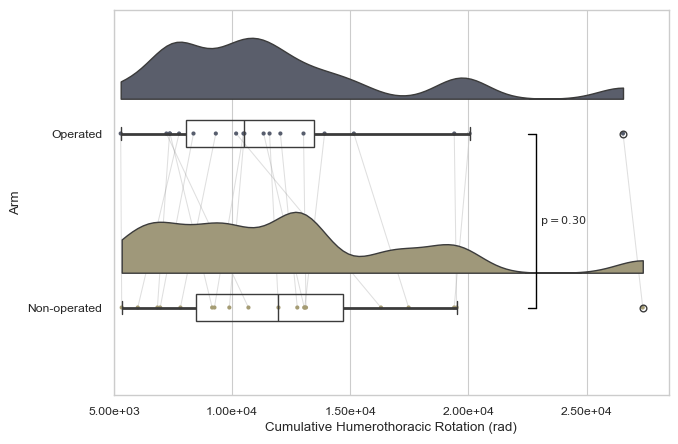

In [6]:
# -------------------------------------------------------------------
# Prep data for plotting
# -------------------------------------------------------------------
df_long = pd.melt(
    cumulative_totals,
    id_vars=["participant"],
    value_vars=["Operated", "Non-operated"],
    var_name="side",
    value_name="total",
)

# -------------------------------------------------------------------
# Make Raincloud
# -------------------------------------------------------------------
fig, ax = plt.subplots(figsize=fig_size)

# Overlay paired observations first
for participant, group in df_long.groupby("participant"):
    if len(group) == 2:
        x = [
            group.loc[group["side"] == "Operated", "total"].iloc[0],
            group.loc[group["side"] == "Non-operated", "total"].iloc[0],
        ]

        ax.plot(
            x,
            [0, 1],
            color="gray",
            alpha=0.25,
            linewidth=0.75,
            zorder=0,
        )

# Create raincloud plot
pt.RainCloud(
    data=df_long,
    x="side",
    y="total",
    jitter=False,
    palette=palette,
    hue="side",
    bw=0.2,
    width_viol=0.7,
    orient="h",
    ax=ax,
)

ax.set_xlabel("Cumulative Humerothoracic Rotation (rad)")
ax.set_ylabel("Arm")
# ax.set_title(
#     "Distribution of Cumulative Humerothoracic Rotation "
#     "in Operated vs. Non-Operated Sides"
# )
ax.xaxis.set_major_formatter(StrMethodFormatter("{x:.2e}"))
ax.set_xlim(left=5e3)  # I manually set this after seeing the plot.


# -------------------------------------------------------------------
# Annotate p-value
# -------------------------------------------------------------------

# Determine x-position for the annotation
annotation_x_pos = 2.2e4
x_min = 5e3
x_range = annotation_x_pos - x_min

x_bracket = annotation_x_pos + 0.05 * x_range
bracket_width = 0.02 * x_range

# Draw bracket
ax.plot(
    [x_bracket, x_bracket],
    [0, 1],
    color="black",
    linewidth=1,
)

ax.plot(
    [x_bracket - bracket_width, x_bracket],
    [0, 0],
    color="black",
    linewidth=1,
)

ax.plot(
    [x_bracket - bracket_width, x_bracket],
    [1, 1],
    color="black",
    linewidth=1,
)

# Add p-value text
ax.text(
    x_bracket + 0.01 * x_range,
    0.5,
    f"$p = {p_value:.2f}$",
    ha="left",
    va="center",
    fontsize=8,
)



plt.show()

## Rotation in each bin
Let's perform the following tasks:
- Calculate mean (std) cumulative motion for RTSA in each bin.
- Create matrix (heatmap) of `poe` x `elevation` showing mean (std) `trace_motion` in each cell
- Create 3D heatmap of avg `trace_motion` in each cell.

**Optional:**
- _(Optional)_ matrix (heatmap) of `poe` x `elevation` showing mean (std) `elevation` in each cell
- _(Optional)_ matrix (heatmap) of `poe` x `elevation` showing mean (std) `IR_ER` in each cell

In [7]:
# calculate mean and std for each bin of poe and elevation
import numpy as np

# Extract the heatmap ndarray from each data object
heatmaps = np.stack([participant.operated[0].humerothoracic.heatmap.cumulative_motion for participant in results], axis=0)

# Shape: (n_participants, n_rows, n_cols)
print(heatmaps.shape)

# Calculate statistics across participants
mean_heatmap = np.mean(heatmaps, axis=0)
std_heatmap = np.std(heatmaps, axis=0, ddof=1)  # Use ddof=1 for sample standard deviation

print(f"Mean heatmap shape: {mean_heatmap.shape}")
print(f"Std heatmap shape: {std_heatmap.shape}")

(20, 9, 18)
Mean heatmap shape: (9, 18)
Std heatmap shape: (9, 18)


Awesome, now let's create that 2D heatmap

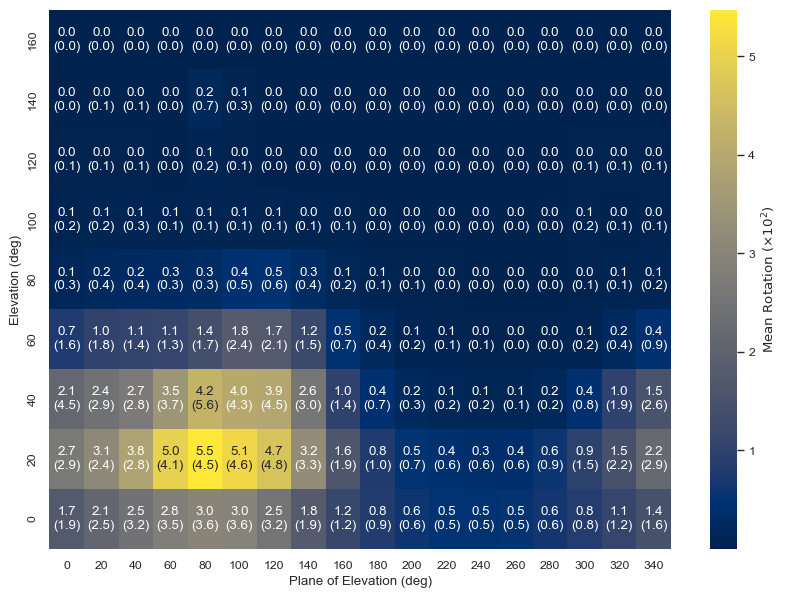

In [ ]:
# plot the heatmap with mean and std
x_min = 0
x_max = results[0].operated[0].humerothoracic.heatmap.poe_range_end
y_min = 0
y_max = results[0].operated[0].humerothoracic.heatmap.elevation_range_end
step = results[0].operated[0].humerothoracic.heatmap.bin_width

# Create bin-center coordinates
x = np.arange(x_min, x_max, step)
y = np.arange(y_min, y_max, step)

# Scale values by 10^2 for display
mean_scaled = mean_heatmap / 100
std_scaled = std_heatmap / 100

# Create annotation strings: "mean (std)"
annotations = np.empty(mean_heatmap.shape, dtype=object)

for i in range(mean_heatmap.shape[0]):
    for j in range(mean_heatmap.shape[1]):
        annotations[i, j] = (
            f"{mean_scaled[i, j]:.1f}\n"
            f"({std_scaled[i, j]:.1f})"
        )

# Create heatmap
fig, ax = plt.subplots(figsize=tuple(x*1.4 for x in fig_size))

sns.heatmap(
    mean_scaled,
    annot=annotations,
    fmt="",
    cmap=palette,
    xticklabels=x,
    yticklabels=y,
    cbar_kws={"label": r"Mean Rotation ($\times 10^2$)"},
    ax=ax,
)

ax.invert_yaxis()
ax.set_xlabel("Plane of Elevation (deg)")
ax.set_ylabel("Elevation (deg)")
# ax.set_title(
#     "Mean (SD) of Cumulative Humerothoracic Rotation "
#     "in Each Range of Elevation and Plane of Elevation"
# )


plt.show()

And now let's make that 3D heatmap

Actually, this is so extra LOL. I don't think the user gets any information from a 3D map that they can't see half of the data from. I think it would be best to just give this 2D heatmap paired with a diagram of how the human body is oriented relative to it.